# Tree Survival Prediction Model

Using `forest_inventory_dataset_1000.csv` to predict whether a tree will survive based on species, location, age, size, and soil type.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

%matplotlib inline
sns.set_style('whitegrid')

## 1. Load Dataset

In [2]:
df = pd.read_csv('forest_inventory_dataset_1000 - forest_inventory_dataset_1000.csv')
df.head()

,Tree_ID,Species,Barangay,Municipality,Latitude,Longitude,Age_Years,Height_m,Diameter_cm,Soil_Type,Survival_Status
0,T0001,Yakal,Libertad,Bunawan,8.374540,126.426071,11,20.5,26.9,Sandy,Alive
1,T0002,Gmelina,Salvacion,Talacogon,8.099975,125.688873,5,11.4,12.5,Clay,Alive
2,T0003,Yakal,Libertad,San Francisco,8.969910,126.248664,6,13.0,16.3,Sandy,Alive
3,T0004,Molave,Libertad,Bislig,8.023062,125.787162,15,26.4,31.5,Loam,Alive
4,T0005,Narra,San Roque,Bunawan,8.456070,126.177764,3,5.6,6.5,Clay,Dead


## 2. Basic Information

In [3]:
print(f'Shape: {df.shape}')
print(f'\nData types:')
print(df.dtypes)
print(f'\nMissing values:')
print(df.isnull().sum())
print(f'\nTarget distribution:')
print(df['Survival_Status'].value_counts())

Shape: (1000, 11)

Data types:
Tree_ID                str
Species                str
Barangay               str
Municipality           str
Latitude           float64
Longitude          float64
Age_Years            int64
Height_m           float64
Diameter_cm        float64
Soil_Type              str
Survival_Status        str
dtype: object

Missing values:
Tree_ID            0
Species            0
Barangay           0
Municipality       0
Latitude           0
Longitude          0
Age_Years          0
Height_m           0
Diameter_cm        0
Soil_Type          0
Survival_Status    0
dtype: int64

Target distribution:
Survival_Status
Alive    645
Dead     355
Name: count, dtype: int64


## 3. Exploratory Data Analysis

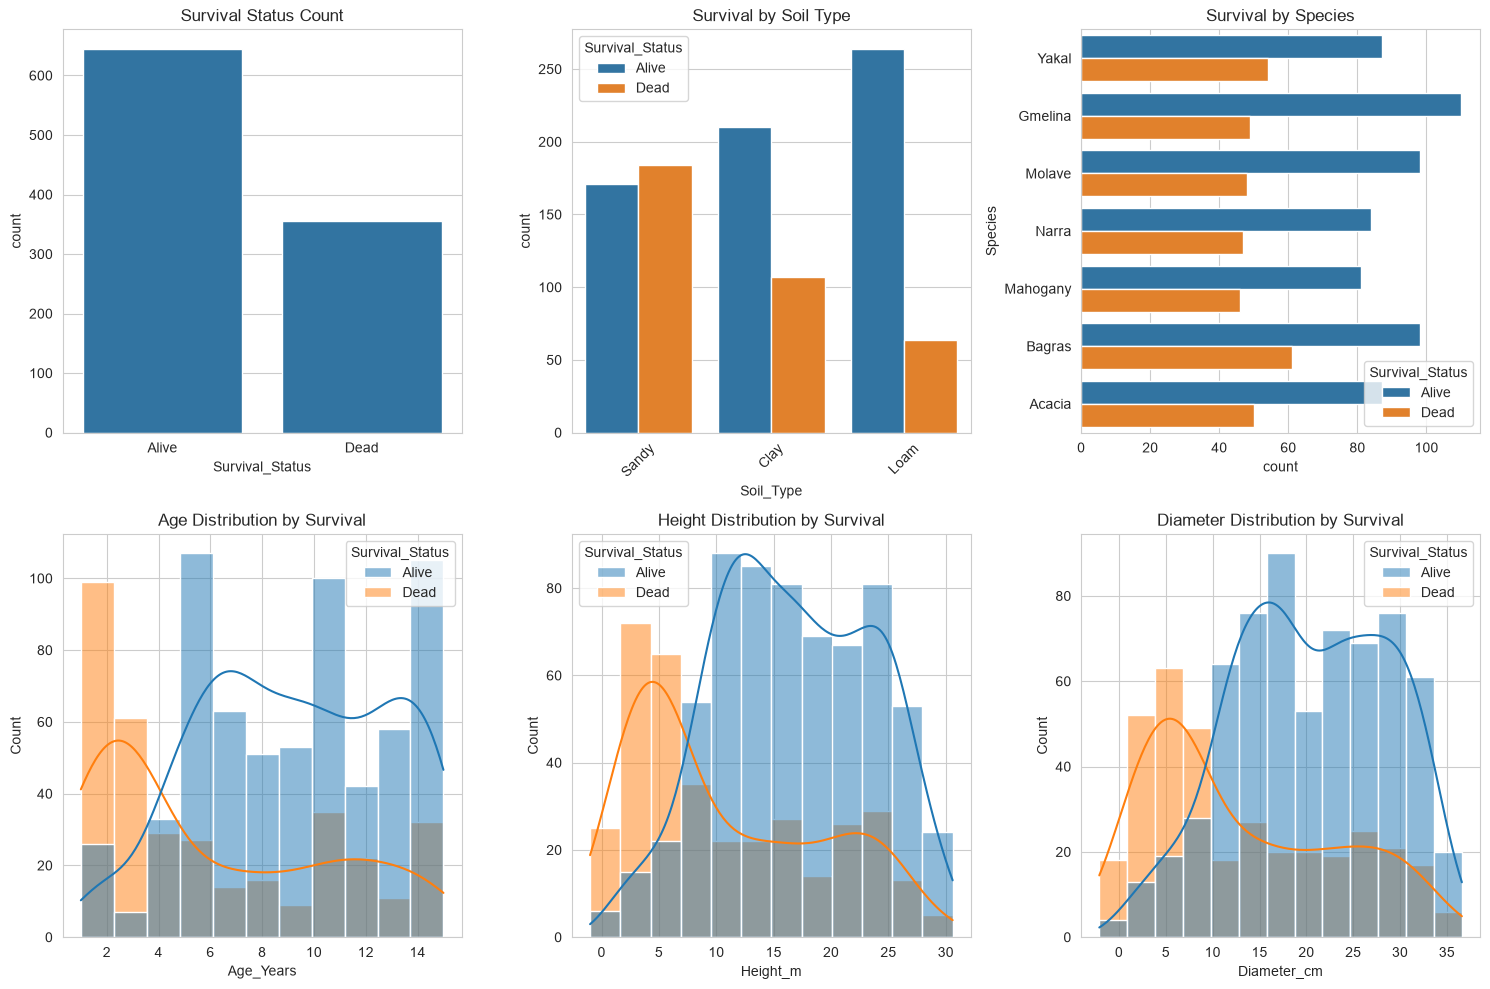

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.countplot(data=df, x='Survival_Status', ax=axes[0, 0])
axes[0, 0].set_title('Survival Status Count')

sns.countplot(data=df, x='Soil_Type', hue='Survival_Status', ax=axes[0, 1])
axes[0, 1].set_title('Survival by Soil Type')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, y='Species', hue='Survival_Status', ax=axes[0, 2])
axes[0, 2].set_title('Survival by Species')

sns.histplot(data=df, x='Age_Years', hue='Survival_Status', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Age Distribution by Survival')

sns.histplot(data=df, x='Height_m', hue='Survival_Status', kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Height Distribution by Survival')

sns.histplot(data=df, x='Diameter_cm', hue='Survival_Status', kde=True, ax=axes[1, 2])
axes[1, 2].set_title('Diameter Distribution by Survival')

plt.tight_layout()
plt.show()

## 4. Preprocessing

Encode categorical variables and split into train/test sets.

In [5]:
df_model = df.drop('Tree_ID', axis=1).copy()

cat_cols = ['Species', 'Barangay', 'Municipality', 'Soil_Type']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

df_model['Survival_Status'] = LabelEncoder().fit_transform(df_model['Survival_Status'])

X = df_model.drop('Survival_Status', axis=1)
y = df_model['Survival_Status']

print(f'Feature matrix: {X.shape}')
print(f'Target vector: {y.shape}')
print(f'Classes: {y.unique()} (0=Dead, 1=Alive)')

Feature matrix: (1000, 9)
Target vector: (1000,)
Classes: [0 1] (0=Dead, 1=Alive)


## 5. Train / Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (800, 9), Test: (200, 9)


## 6. Train Random Forest Model

In [7]:
rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print('Model training complete.')

Model training complete.


## 7. Evaluate Model

In [8]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC AUC:  {roc_auc_score(y_test, y_proba):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Dead', 'Alive']))
print(f'\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7950
ROC AUC:  0.8539

Classification Report:
              precision    recall  f1-score   support

        Dead       0.82      0.87      0.85       129
       Alive       0.73      0.66      0.70        71

    accuracy                           0.80       200
   macro avg       0.78      0.77      0.77       200
weighted avg       0.79      0.80      0.79       200


Confusion Matrix:
[[112  17]
 [ 24  47]]


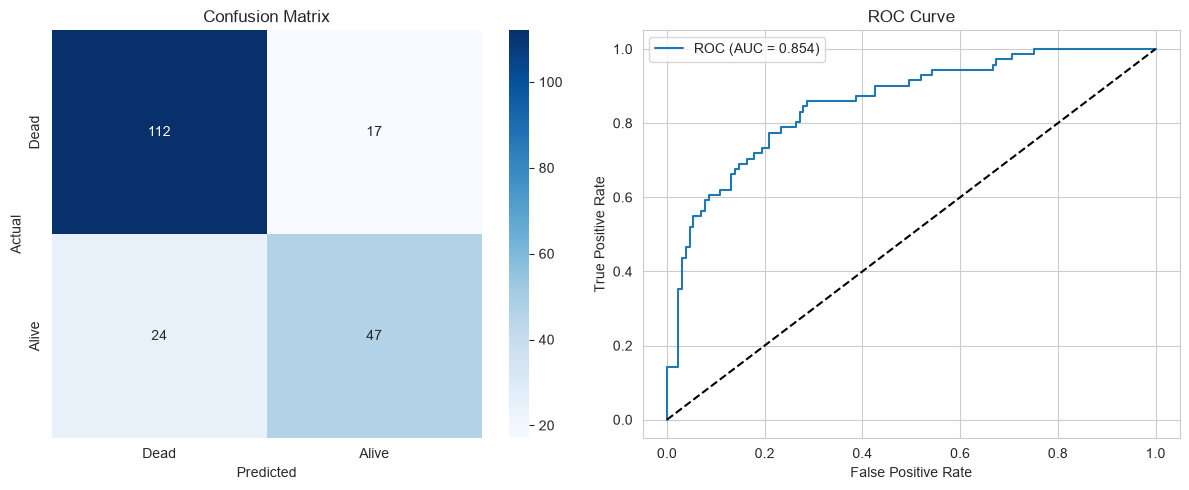

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dead', 'Alive'], yticklabels=['Dead', 'Alive'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc_score(y_test, y_proba):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Feature Importance

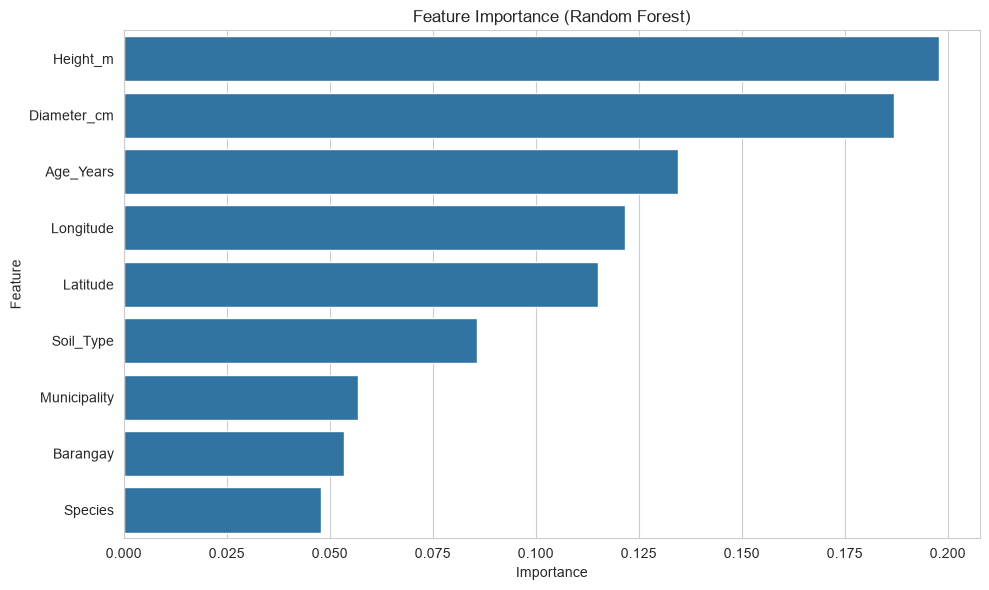

,Feature,Importance
6,Height_m,0.197937
7,Diameter_cm,0.186859
5,Age_Years,0.134572
4,Longitude,0.121594
3,Latitude,0.115143
8,Soil_Type,0.085700
2,Municipality,0.056812
1,Barangay,0.053446
0,Species,0.047937


In [10]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importance', y='Feature')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

importances

## 9. Predict on New Trees

Create a small sample of new tree records and predict their survival.

In [11]:
new_trees = pd.DataFrame([
    ['Yakal', 'Libertad', 'Bunawan', 8.37, 126.43, 5, 10.0, 12.0, 'Sandy'],
    ['Gmelina', 'Salvacion', 'Talacogon', 8.10, 125.69, 15, 25.0, 30.0, 'Clay'],
    ['Narra', 'Libertad', 'Bislig', 8.02, 125.79, 20, 30.0, 40.0, 'Loam']
], columns=['Species', 'Barangay', 'Municipality', 'Latitude', 'Longitude',
           'Age_Years', 'Height_m', 'Diameter_cm', 'Soil_Type'])

new_trees_encoded = new_trees.copy()
for col in cat_cols:
    new_trees_encoded[col] = encoders[col].transform(new_trees_encoded[col])

predictions = rf.predict(new_trees_encoded)
probas = rf.predict_proba(new_trees_encoded)[:, 1]

new_trees['Prediction'] = ['Alive' if p == 1 else 'Dead' for p in predictions]
new_trees['Survival_Prob'] = probas.round(4)

new_trees

,Species,Barangay,Municipality,Latitude,Longitude,Age_Years,Height_m,Diameter_cm,Soil_Type,Prediction,Survival_Prob
0,Yakal,Libertad,Bunawan,8.37,126.43,5,10.0,12.0,Sandy,Dead,0.1939
1,Gmelina,Salvacion,Talacogon,8.10,125.69,15,25.0,30.0,Clay,Dead,0.0918
2,Narra,Libertad,Bislig,8.02,125.79,20,30.0,40.0,Loam,Dead,0.2019
